I had created a data that roughly follows the line -> y = 2x + 5

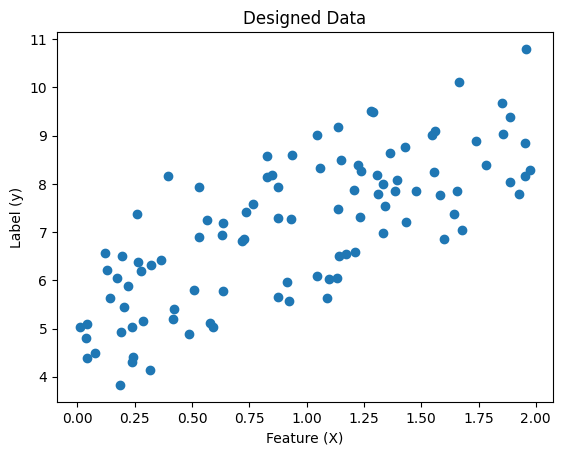

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 5 + 2 * X + np.random.randn(100, 1) 

plt.scatter(X, y)
plt.xlabel("Feature (X)")
plt.ylabel("Label (y)")
plt.title("Designed Data")
plt.show()


In [2]:
def cost_compute(X, y, w, b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        cost += float((w * X[i] + b - y[i]) ** 2)
    cost /= (2 * m)
    return cost

In [3]:
def gradient(X, y, w, b):
    m = X.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        dj_dw += (w * X[i] + b - y[i]) * X[i]
        dj_db += (w * X[i] + b - y[i])
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [4]:
def gradient_descent(X, y, w, b, alpha, iteration):
    m = X.shape[0]

    for _ in range(iteration):
        dj_dw, dj_db = gradient(X, y, w, b)
        w = float(w - alpha * dj_dw)
        b = float(b - alpha * dj_db)
    
    return w, b

In [5]:
initial_w = 2
initial_b = 1
alpha = 0.1
iteration = 1000
w, b = gradient_descent(X, y, initial_w, initial_b, alpha, iteration)
print(f"w, b: {w:.3f} {b:.3f}")

C:\Users\AADISH\AppData\Local\Temp\ipykernel_20872\3871670781.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w = float(w - alpha * dj_dw)
C:\Users\AADISH\AppData\Local\Temp\ipykernel_20872\3871670781.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b = float(b - alpha * dj_db)


w, b: 1.968 5.222


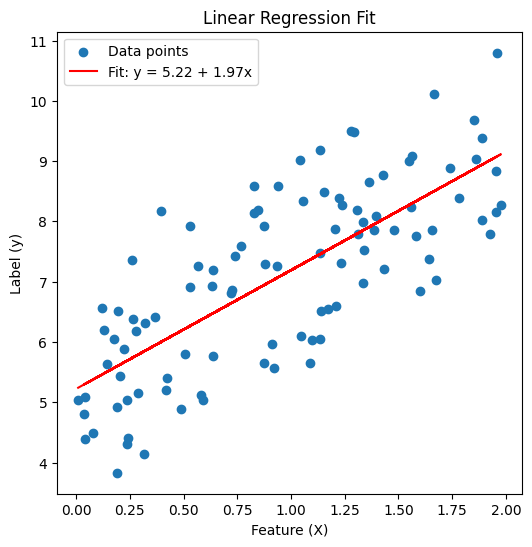

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(X, y, label="Data points")
plt.plot(X, w * X + b, color="red", label=f"Fit: y = {b:.2f} + {w:.2f}x")
plt.xlabel("Feature (X)")
plt.ylabel("Label (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

**Variance Decomposition**

- **Total Sum of Squares (TSS)** measures the overall variance in the data:

  $$\displaystyle TSS = \sum_{i}(y_i - \bar y)^2$$

- **Explained Sum of Squares (ESS)** is the variance captured by our model:

  $$\displaystyle ESS = \sum_{i}(\hat y_i - \bar y)^2$$

- **Residual Sum of Squares (RSS)** is the variance left over (errors):

  $$\displaystyle RSS = \sum_{i}(y_i - \hat y_i)^2$$

They satisfy:

$$
TSS = ESS + RSS
$$


**Computing TSS, ESS, RSS:**

In [7]:
y_pred = w * X + b

y_mean = np.mean(y)

TSS = np.sum((y - y_mean) ** 2)

ESS = np.sum((y_pred - y_mean) ** 2)

RSS = np.sum((y - y_pred) ** 2)

print(f"TSS = {TSS:.4f}")
print(f"ESS = {ESS:.4f}")
print(f"RSS = {RSS:.4f}")

TSS = 228.0720
ESS = 128.8281
RSS = 99.2439
